Exploratory Data Analysis

In [1]:
# import data
import pandas as pd
import numpy as np

# Load data files
file_data_path='MY Stock Market 2000-01-03 .csv'

# Read data file
with open(file_data_path,'r') as f:
    data_content=f.readlines()

missing_values=['n/a','na','--','?']

df=pd.read_csv(file_data_path)

df.replace(missing_values,np.nan,inplace=True)

df.head()

,Unnamed: 0,Date,Ticker,Company_Name,Open,High,Low,Close,Adj Close,Volume
0,0,2002-08-13,3A.KL,THREE-A RESOURCES BHD,0.110,0.110,0.110,0.110,0.078549,0.0
1,1,2002-08-14,3A.KL,THREE-A RESOURCES BHD,0.108,0.108,0.108,0.108,0.077121,3165250.0
2,2,2002-08-15,3A.KL,THREE-A RESOURCES BHD,0.112,0.112,0.112,0.112,0.079977,1940250.0
3,3,2002-08-16,3A.KL,THREE-A RESOURCES BHD,0.110,0.110,0.110,0.110,0.078549,1231250.0
4,4,2002-08-19,3A.KL,THREE-A RESOURCES BHD,0.108,0.108,0.108,0.108,0.077121,2106500.0


In [2]:
df.isnull().sum()

Unnamed: 0          0
Date                0
Ticker              0
Company_Name        0
Open            85759
High            85759
Low             85759
Close           85759
Adj Close       85759
Volume          85759
dtype: int64

In [3]:
# Replace 'n/a','na','--','?' with Nan
df.dropna(inplace=True)
df.isnull().sum()

Unnamed: 0      0
Date            0
Ticker          0
Company_Name    0
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
dtype: int64

In [8]:
# Group Name: HappyGoLucky
# Member 1: CHIA JIUN YUAN
# Member 2: BEH SONG YOU
# Member 3: LAU SHE HONG
# Member 4: HIEW CHENG HAN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory Data Analysis
# Compute the mean, sum, range and other interesting statistics for numeric columns.

numeric_columns=['Open','High','Low','Close','Adj Close','Volume']
eda=pd.DataFrame({
    'Mean':df[numeric_columns].mean(),
    'Sum':df[numeric_columns].sum(),
    'Min':df[numeric_columns].min(),
    'Max':df[numeric_columns].max(),
    'Range':df[numeric_columns].max()-df[numeric_columns].min(),
    'Median':df[numeric_columns].median(),
    'Std Dev':df[numeric_columns].std(),
    'Skewness':df[numeric_columns].skew(),
    'Kurtosis':df[numeric_columns].kurt(),
    '25th Percentile':df[numeric_columns].quantile(0.25),
    '75th Percentile':df[numeric_columns].quantile(0.75)
}).T

# Display EDA Statistics
print(eda)

                          Open           High            Low          Close  \
Mean                  1.774666       1.797188       1.753387       1.776414   
Sum              821052.772311  831472.486592  811207.900075  821861.391719   
Min                   0.002933       0.002933       0.002933       0.002933   
Max                 525.000000     547.500000     475.000000     477.500000   
Range               524.997067     547.497067     474.997067     477.497067   
Median                0.666666       0.677272       0.656666       0.670000   
Std Dev               8.127995       8.218818       8.009219       8.101338   
Skewness             34.857845      34.725244      34.850572      34.733650   
Kurtosis           1641.680868    1628.987252    1644.766176    1631.973251   
25th Percentile       0.306665       0.315000       0.300000       0.309998   
75th Percentile       1.539998       1.558329       1.518180       1.540000   

                     Adj Close        Volume  
Mean

In [9]:
# Compute Average Price
df['Average Price']=df[['Open','Close']].mean(axis=1)

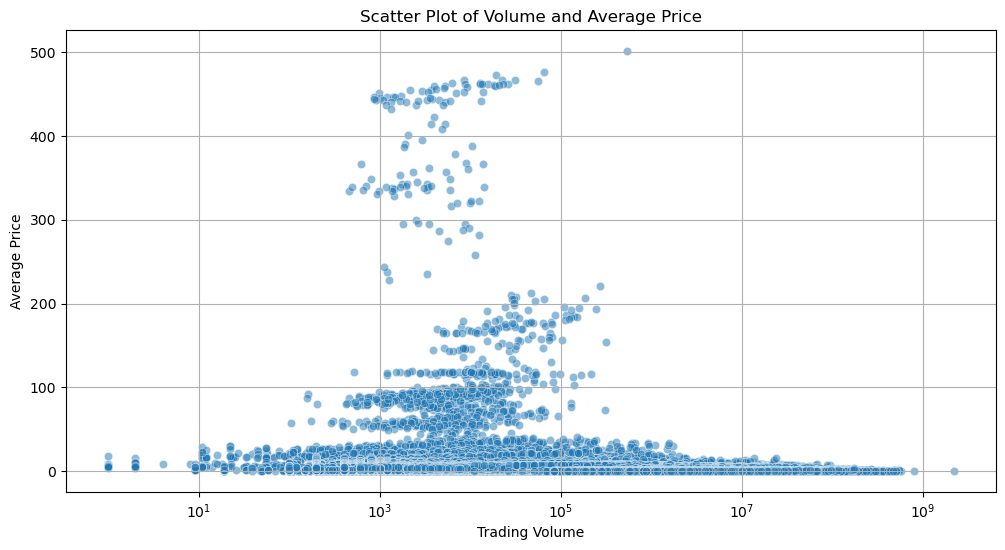

In [10]:
# scatter plot show price-volume relation
plt.figure(figsize=(12,6))
sns.scatterplot(x=df['Volume'],y=df['Average Price'],alpha=0.5)
plt.xlabel('Trading Volume')
plt.ylabel('Average Price')
plt.title('Scatter Plot of Volume and Average Price')
plt.xscale('log')
plt.grid(True)

# price-volume relation plot
plt.show()

In [11]:
# Compute correlation matrix AND Pearson correlation coefficient
correlation_matrix = df[['Volume','Average Price']].corr()
correlation_value = correlation_matrix.loc['Volume','Average Price']

# Display correlation results
print("Pearson correlation between Volume and Average Price:",round(correlation_value,3))


Pearson correlation between Volume and Average Price: -0.017


In [12]:
# sns.pairplot(df[numeric_columns])
# plt.suptitle('Pairplot of Numeric Variables',y=1.0)
# plt.show()

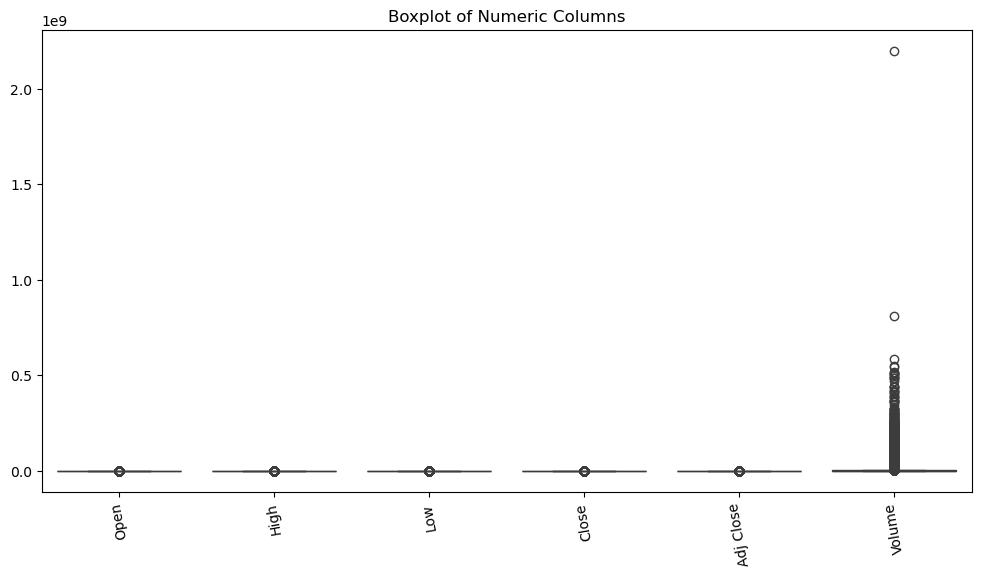

In [13]:
#Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_columns])
plt.title('Boxplot of Numeric Columns')
plt.xticks(rotation=100)
plt.show()

In [14]:
#Daily rate of return statistics
df['Daily Return']=df['Close'].pct_change()*100
print("Daily rate of return statistics：\n",df['Daily Return'].describe())

Daily rate of return statistics：
 count    462651.000000
mean          0.753003
std         307.291502
min         -98.307872
25%          -1.242236
50%           0.000000
75%           0.990099
max      207508.695652
Name: Daily Return, dtype: float64


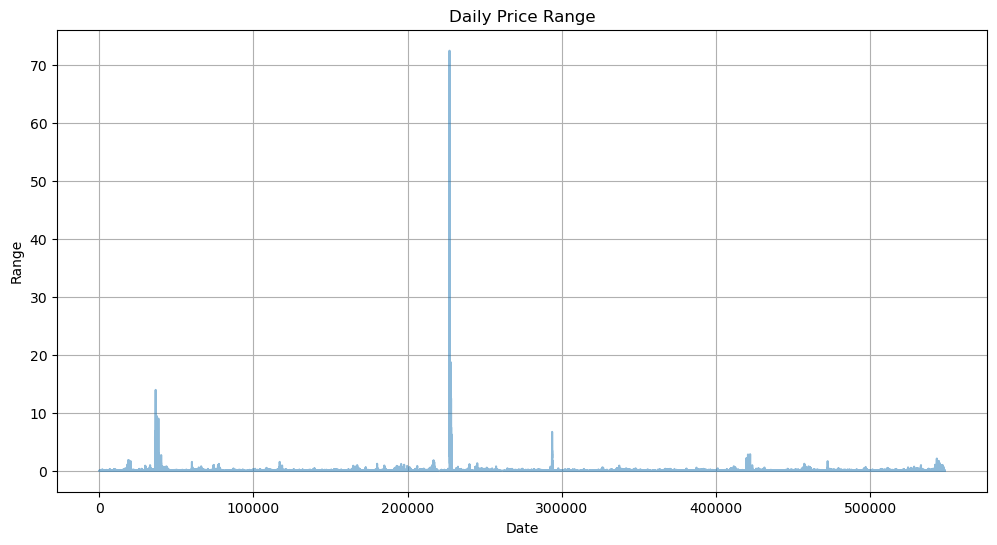

In [15]:
#Daily Price Range
df['Daily Range']=df['High']-df['Low']
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Daily Range'],alpha=0.5)
plt.title('Daily Price Range')
plt.xlabel('Date')
plt.ylabel('Range')
plt.grid(True)
plt.show()

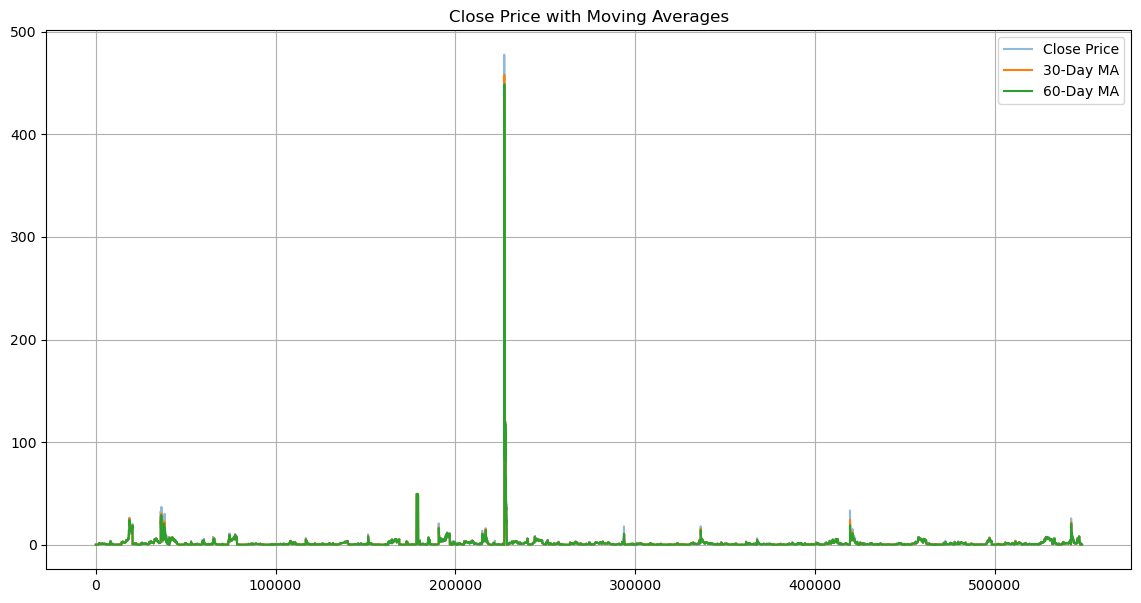

In [16]:
#Moving Average
df['30 Day MA']=df['Close'].rolling(30).mean()
df['60 Day MA']=df['Close'].rolling(60).mean()
plt.figure(figsize=(14,7))
plt.plot(df.index, df['Close'],label='Close Price',alpha=0.5)
plt.plot(df.index, df['30 Day MA'],label='30-Day MA')
plt.plot(df.index, df['60 Day MA'],label='60-Day MA')
plt.title('Close Price with Moving Averages')
plt.legend()
plt.grid(True)
plt.show()

Total transaction volume for each company：
                        Company_Name        Volume
26                      EKOVEST BHD  4.135722e+10
53              IOI CORPORATION BHD  3.968848e+10
55  ISKANDAR WATERFRONT CITY BERHAD  3.667552e+10
7               AXIATA GROUP BERHAD  3.004040e+10
35                       GAMUDA BHD  2.933636e+10
70           MINETECH RESOURCES BHD  2.730828e+10
50              IJM CORPORATION BHD  2.691354e+10
72                MQ TECHNOLOGY BHD  2.578049e+10
46               HO WAH GENTING BHD  2.281817e+10
76                     NOVA MSC BHD  2.271253e+10


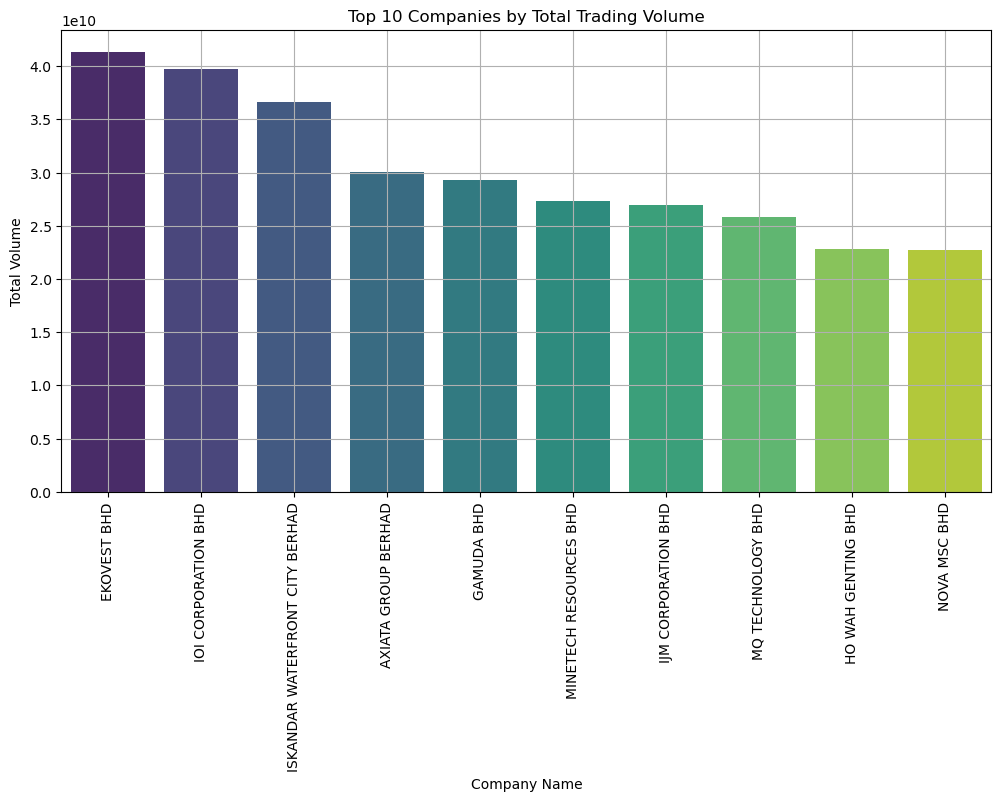

Trading volume statistics for each company：
                    Company_Name          mean     median           std    min  \
0             ABM FUJIYA BERHAD  1.131246e+05    21550.0  7.660307e+05  100.0   
1              AHB HOLDINGS BHD  2.034578e+06   134499.0  7.745062e+06    0.0   
2             AJINOMOTO (M) BHD  2.669170e+04    10400.0  5.626448e+04    0.0   
3    ALAM MARITIM RESOURCES BHD  5.071063e+06  1237061.0  1.613022e+07  149.0   
4             APB RESOURCES BHD  1.966945e+05    31500.0  6.616134e+05    0.0   
..                          ...           ...        ...           ...    ...   
113          UNITED MALACCA BHD  5.684330e+04    27000.0  1.280581e+05    0.0   
114                    UZMA BHD  1.890568e+06   401350.0  4.452789e+06    0.0   
115     WEGMANS HOLDINGS BERHAD  1.742380e+06   359500.0  4.372245e+06  100.0   
116            YNH PROPERTY BHD  1.205025e+06   317873.0  7.022328e+06    0.0   
117                YONG TAI BHD  1.066865e+06    23699.0  5.4386

In [17]:
#Group companies and calculate total transaction volume
company_volume=df.groupby('Company_Name')['Volume'].sum().reset_index()
company_volume=company_volume.sort_values(by='Volume',ascending=False).head(10)

#Displays the total transaction
print("Total transaction volume for each company：\n",company_volume)

plt.figure(figsize=(12,6))
sns.barplot(x='Company_Name',y='Volume',data=company_volume,hue='Company_Name',palette='viridis',legend=False)
plt.title('Top 10 Companies by Total Trading Volume')
plt.xlabel('Company Name')
plt.ylabel('Total Volume')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

company_volume_stats = df.groupby('Company_Name')['Volume'].agg(['mean', 'median', 'std', 'min', 'max']).reset_index()
print("Trading volume statistics for each company：\n",company_volume_stats)